In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATA_PATH = "/content/drive/MyDrive/datasets/raw/"

In [6]:
import os


print(os.listdir("/content/drive"))

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [7]:


print(os.listdir("/content/drive/MyDrive/datasets/raw"))

['application_test.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'sample_submission.csv', 'previous_application.csv', 'README.md', 'application_train.csv']


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [10]:
df = pd.read_csv(DATA_PATH + "application_train.csv")

In [ ]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [12]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [14]:
df.shape

(307511, 122)

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
print("Total rows:", len(df))
print("Unique SK_ID_CURR:", df['SK_ID_CURR'].nunique())
print("One row per applicant:", len(df) == df['SK_ID_CURR'].nunique())

Total rows: 307511
Unique SK_ID_CURR: 307511
One row per applicant: True


In [15]:
# Basic info
print(df.dtypes.value_counts())
print("\n")
df.head()

float64    65
int64      41
object     16
Name: count, dtype: int64




,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


TARGET
0    282686
1     24825
Name: count, dtype: int64

Class Distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


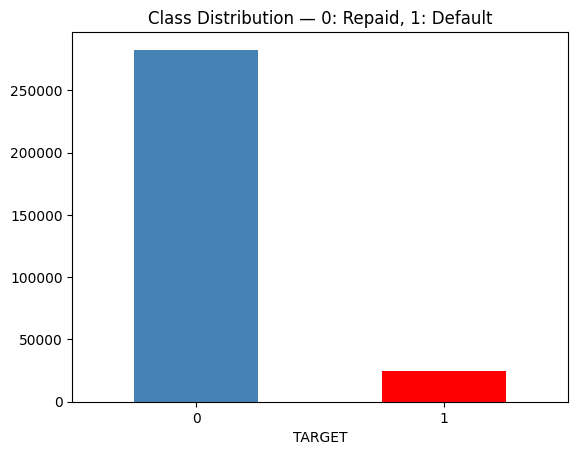

In [17]:
print(df['TARGET'].value_counts())
print("\nClass Distribution:")
print(df['TARGET'].value_counts(normalize=True))

df['TARGET'].value_counts().plot(kind='bar', color=['steelblue','red'])
plt.title('Class Distribution — 0: Repaid, 1: Default')
plt.xticks(rotation=0)
plt.show()

In [18]:
df.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519
AMT_REQ_CREDIT_BUREAU_WEEK,41519
AMT_REQ_CREDIT_BUREAU_MON,41519
AMT_REQ_CREDIT_BUREAU_QRT,41519


In [24]:
percent=df.isna().sum()/len(df)*100

In [25]:
percent

,0
SK_ID_CURR,0.000000
TARGET,0.000000
NAME_CONTRACT_TYPE,0.000000
CODE_GENDER,0.000000
FLAG_OWN_CAR,0.000000
...,...
AMT_REQ_CREDIT_BUREAU_DAY,13.501631
AMT_REQ_CREDIT_BUREAU_WEEK,13.501631
AMT_REQ_CREDIT_BUREAU_MON,13.501631
AMT_REQ_CREDIT_BUREAU_QRT,13.501631


In [30]:
print(percent.sort_values(ascending=False))

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
                              ...    
FLAG_DOCUMENT_16             0.000000
FLAG_DOCUMENT_15             0.000000
FLAG_DOCUMENT_14             0.000000
FLAG_DOCUMENT_20             0.000000
FLAG_DOCUMENT_21             0.000000
Length: 122, dtype: float64


In [33]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print(cat_cols)

Numeric columns: 106
Categorical columns: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [34]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True) * 100)


--- NAME_CONTRACT_TYPE ---
NAME_CONTRACT_TYPE
Cash loans         90.478715
Revolving loans     9.521285
Name: proportion, dtype: float64

--- CODE_GENDER ---
CODE_GENDER
F      65.834393
M      34.164306
XNA     0.001301
Name: proportion, dtype: float64

--- FLAG_OWN_CAR ---
FLAG_OWN_CAR
N    65.989184
Y    34.010816
Name: proportion, dtype: float64

--- FLAG_OWN_REALTY ---
FLAG_OWN_REALTY
Y    69.367275
N    30.632725
Name: proportion, dtype: float64

--- NAME_TYPE_SUITE ---
NAME_TYPE_SUITE
Unaccompanied      81.159562
Family             13.111205
Spouse, partner     3.713029
Children            1.066884
Other_B             0.578018
Other_A             0.282804
Group of people     0.088499
Name: proportion, dtype: float64

--- NAME_INCOME_TYPE ---
NAME_INCOME_TYPE
Working                 51.631974
Commercial associate    23.289248
Pensioner               18.003258
State servant            7.057634
Unemployed               0.007154
Student                  0.005853
Businessman        

In [35]:
corr_target = df[num_cols].corr()['TARGET'].sort_values()
print("Most negative correlations:\n", corr_target.head(10))
print("\nMost positive correlations:\n", corr_target.tail(10))

Most negative correlations:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64

Most positive correlations:
 FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64


<Axes: >

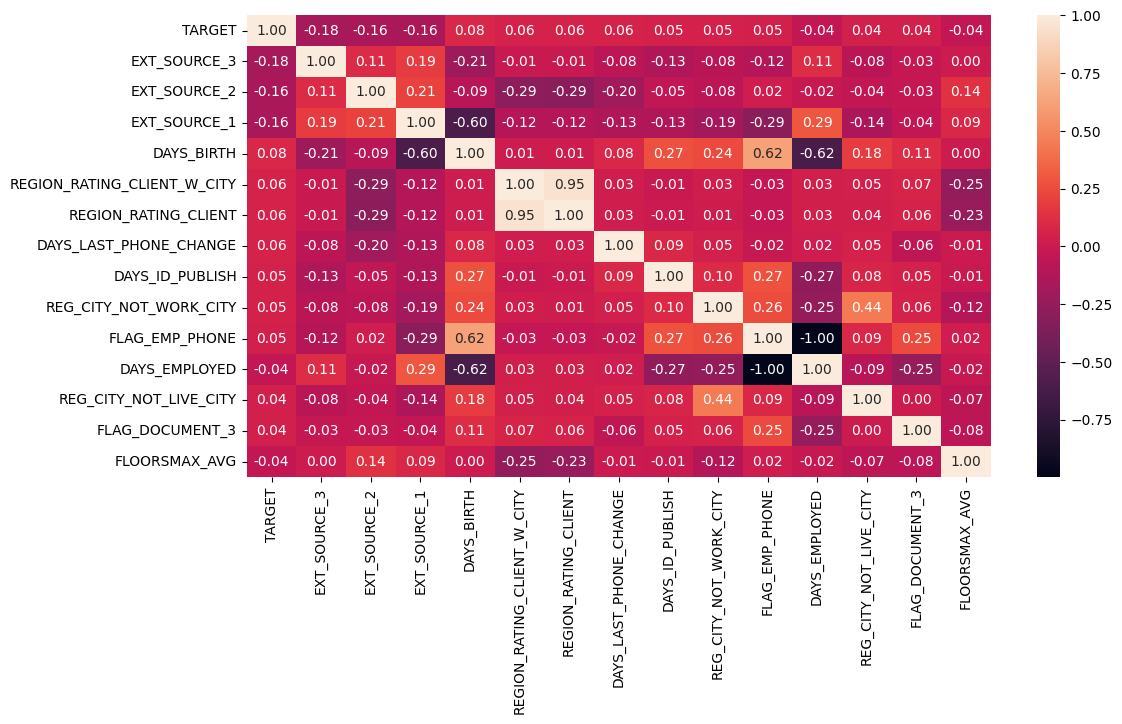

In [39]:
top_corr_cols = corr_target.abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(12, 6))
sns.heatmap(df[top_corr_cols].corr(), annot=True, fmt='.2f')

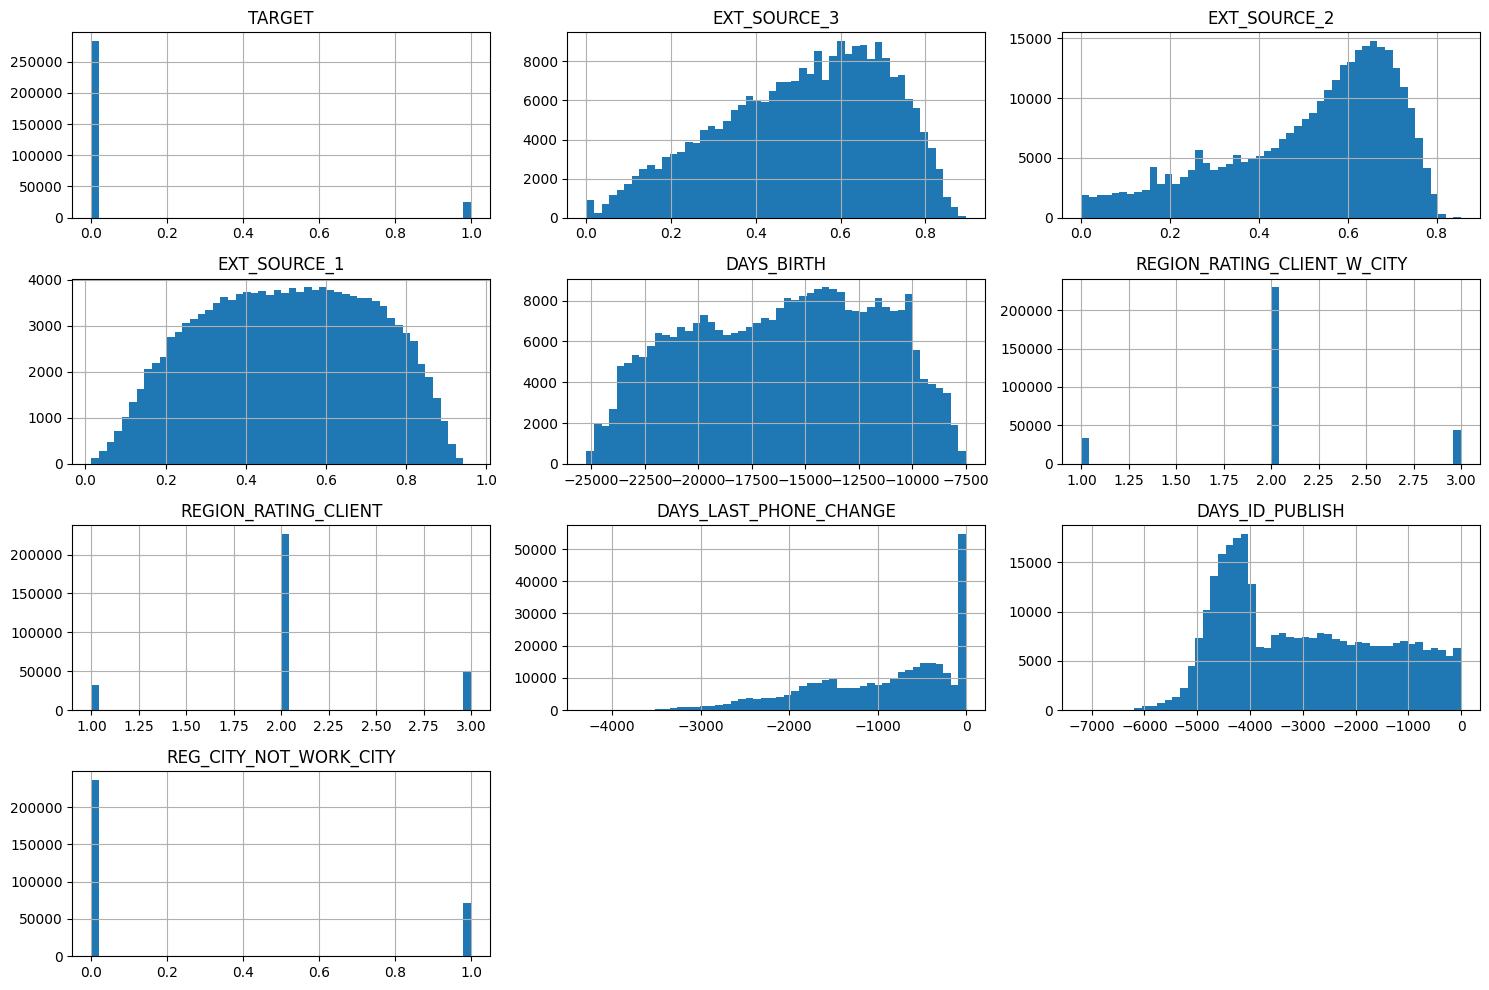

In [43]:
df[top_corr_cols].hist(figsize=(15,10), bins=50)
plt.tight_layout()
plt.show()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


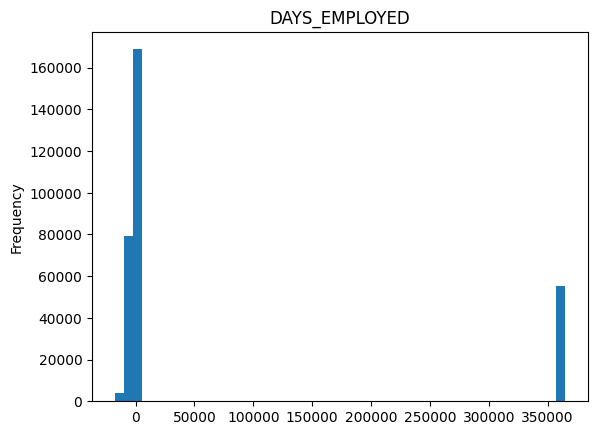

In [40]:
print(df['DAYS_EMPLOYED'].describe())
df['DAYS_EMPLOYED'].plot.hist(bins=50, title='DAYS_EMPLOYED')
plt.show()

In [44]:
# How many rows have this anomalous value?
anomaly_count = (df['DAYS_EMPLOYED'] == 365243).sum()
print("Rows with anomaly:", anomaly_count)
print("Percent of data:", anomaly_count / len(df) * 100)

Rows with anomaly: 55374
Percent of data: 18.00716071945394


In [45]:
df[df['DAYS_EMPLOYED'] == 365243]['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,55352
Unemployed,22


In [46]:
df[df['DAYS_EMPLOYED'] != 365243]['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Working,158774
Commercial associate,71617
State servant,21703
Student,18
Pensioner,10
Businessman,10
Maternity leave,5


In [47]:
# 1. Flag rows before destroying the information
df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

# 2. Replace the sentinel with NaN
df['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)

# Sanity check
print(df['DAYS_EMPLOYED'].describe())
print(df['DAYS_EMPLOYED_ANOM'].value_counts())

count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64
DAYS_EMPLOYED_ANOM
0    252137
1     55374
Name: count, dtype: int64


<Axes: title={'center': 'DAYS_EMPLOYED after cleaning'}, ylabel='Frequency'>

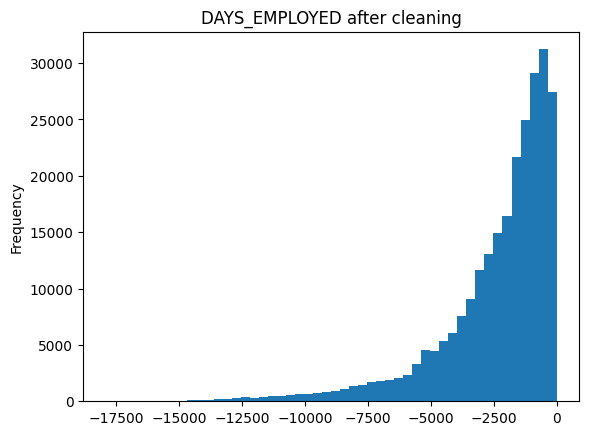

In [48]:
df['DAYS_EMPLOYED'].plot.hist(bins=50, title='DAYS_EMPLOYED after cleaning')

In [49]:
days_cols = [c for c in df.columns if 'DAYS' in c] + ['OWN_CAR_AGE']

for col in days_cols:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].describe())


--- DAYS_BIRTH ---
count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

--- DAYS_EMPLOYED ---
count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64

--- DAYS_REGISTRATION ---
count    307511.000000
mean      -4986.120328
std        3522.886321
min      -24672.000000
25%       -7479.500000
50%       -4504.000000
75%       -2010.000000
max           0.000000
Name: DAYS_REGISTRATION, dtype: float64

--- DAYS_ID_PUBLISH ---
count    307511.000000
mean      -2994.202373
std        1509.450419
min       -7197.000000
25%       -4299.000000
50%       -3254.000000
75%       -1720.000000
max           0.000000
Name: DAYS_ID_PUBLISH, dtype: float64

--- DAYS_LAST_PHONE_C

In [50]:
# Confirm OWN_CAR_AGE is null exactly when FLAG_OWN_CAR == 'N'
pd.crosstab(df['FLAG_OWN_CAR'], df['OWN_CAR_AGE'].isnull())

OWN_CAR_AGE,False,True
FLAG_OWN_CAR,,
N,0,202924
Y,104582,5


In [51]:
# Categorical columns vs TARGET - default rate per category
for col in cat_cols:
    print(f"\n--- {col} vs TARGET ---")
    print(df.groupby(col)['TARGET'].mean().sort_values(ascending=False))


--- NAME_CONTRACT_TYPE vs TARGET ---
NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783
Name: TARGET, dtype: float64

--- CODE_GENDER vs TARGET ---
CODE_GENDER
M      0.101419
F      0.069993
XNA    0.000000
Name: TARGET, dtype: float64

--- FLAG_OWN_CAR vs TARGET ---
FLAG_OWN_CAR
N    0.085002
Y    0.072437
Name: TARGET, dtype: float64

--- FLAG_OWN_REALTY vs TARGET ---
FLAG_OWN_REALTY
N    0.083249
Y    0.079616
Name: TARGET, dtype: float64

--- NAME_TYPE_SUITE vs TARGET ---
NAME_TYPE_SUITE
Other_B            0.098305
Other_A            0.087760
Group of people    0.084871
Unaccompanied      0.081830
Spouse, partner    0.078716
Family             0.074946
Children           0.073768
Name: TARGET, dtype: float64

--- NAME_INCOME_TYPE vs TARGET ---
NAME_INCOME_TYPE
Maternity leave         0.400000
Unemployed              0.363636
Working                 0.095885
Commercial associate    0.074843
State servant           0.057550
Pensioner               0.053864
B

In [52]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    summary = df.groupby(col)['TARGET'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(summary)


--- NAME_CONTRACT_TYPE ---
                        mean   count
NAME_CONTRACT_TYPE                  
Cash loans          0.083459  278232
Revolving loans     0.054783   29279

--- CODE_GENDER ---
                 mean   count
CODE_GENDER                  
M            0.101419  105059
F            0.069993  202448
XNA          0.000000       4

--- FLAG_OWN_CAR ---
                  mean   count
FLAG_OWN_CAR                  
N             0.085002  202924
Y             0.072437  104587

--- FLAG_OWN_REALTY ---
                     mean   count
FLAG_OWN_REALTY                  
N                0.083249   94199
Y                0.079616  213312

--- NAME_TYPE_SUITE ---
                     mean   count
NAME_TYPE_SUITE                  
Other_B          0.098305    1770
Other_A          0.087760     866
Group of people  0.084871     271
Unaccompanied    0.081830  248526
Spouse, partner  0.078716   11370
Family           0.074946   40149
Children         0.073768    3267

--- NAME_INCOM

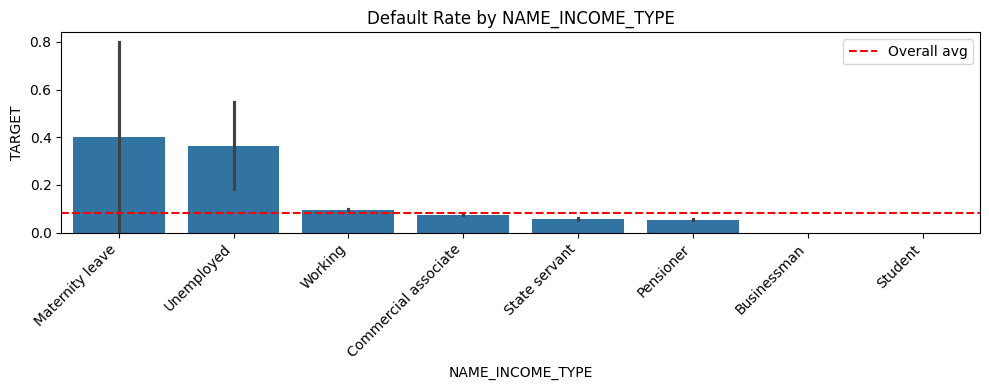

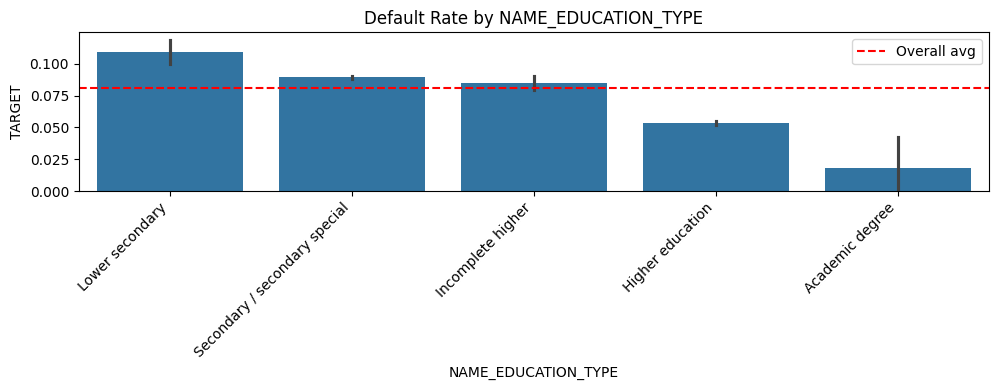

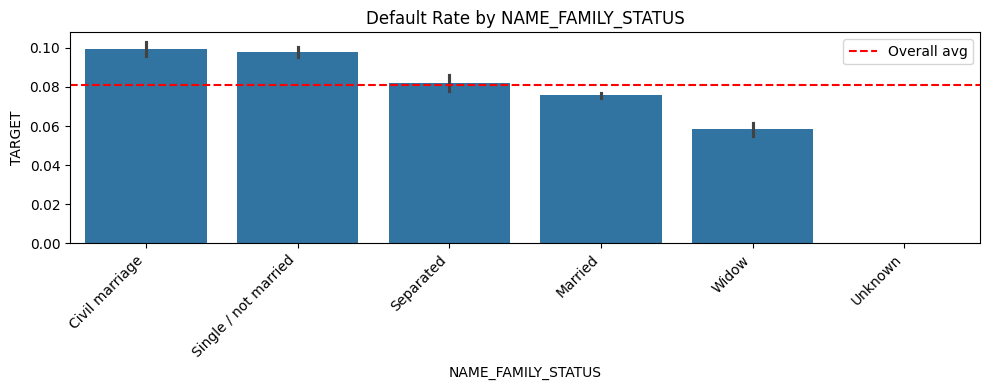

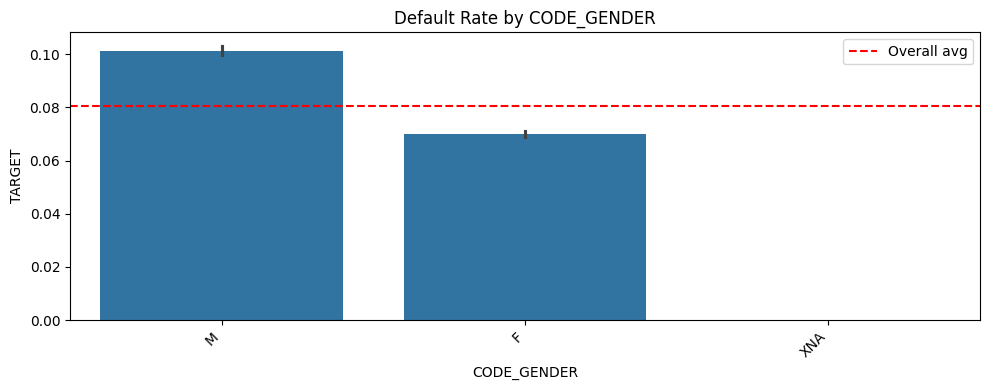

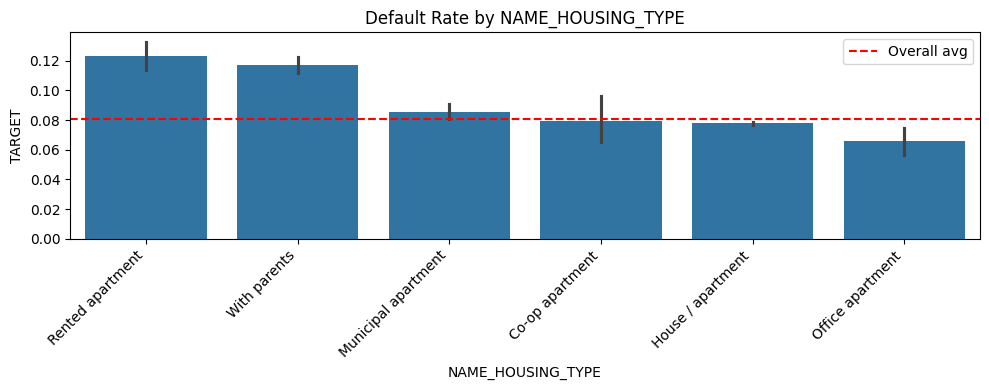

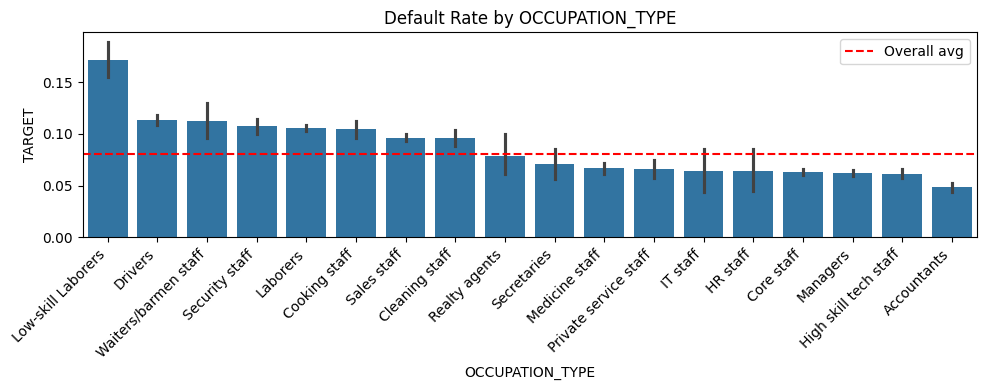

In [53]:
important_cats = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
                   'CODE_GENDER', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

for col in important_cats:
    plt.figure(figsize=(10,4))
    order = df.groupby(col)['TARGET'].mean().sort_values(ascending=False).index
    sns.barplot(x=col, y='TARGET', data=df, order=order)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Default Rate by {col}')
    plt.axhline(df['TARGET'].mean(), color='red', linestyle='--', label='Overall avg')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [54]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print(df[ext_cols].describe().T)
print("\nMissing %:")
print(df[ext_cols].isnull().mean() * 100)
print("\nCorrelation with TARGET:")
print(df[ext_cols + ['TARGET']].corr())

                 count      mean       std           min       25%       50%  \
EXT_SOURCE_1  134133.0  0.502130  0.211062  1.456813e-02  0.334007  0.505998   
EXT_SOURCE_2  306851.0  0.514393  0.191060  8.173617e-08  0.392457  0.565961   
EXT_SOURCE_3  246546.0  0.510853  0.194844  5.272652e-04  0.370650  0.535276   

                   75%       max  
EXT_SOURCE_1  0.675053  0.962693  
EXT_SOURCE_2  0.663617  0.855000  
EXT_SOURCE_3  0.669057  0.896010  

Missing %:
EXT_SOURCE_1    56.381073
EXT_SOURCE_2     0.214626
EXT_SOURCE_3    19.825307
dtype: float64

Correlation with TARGET:
              EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3    TARGET
EXT_SOURCE_1      1.000000      0.213982      0.186846 -0.155317
EXT_SOURCE_2      0.213982      1.000000      0.109167 -0.160472
EXT_SOURCE_3      0.186846      0.109167      1.000000 -0.178919
TARGET           -0.155317     -0.160472     -0.178919  1.000000


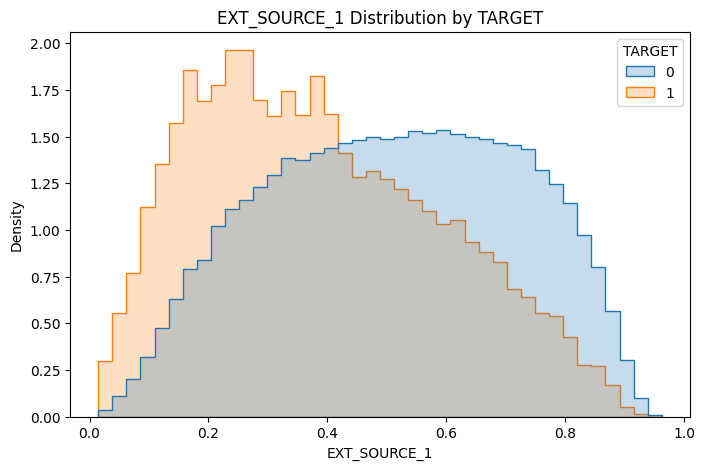

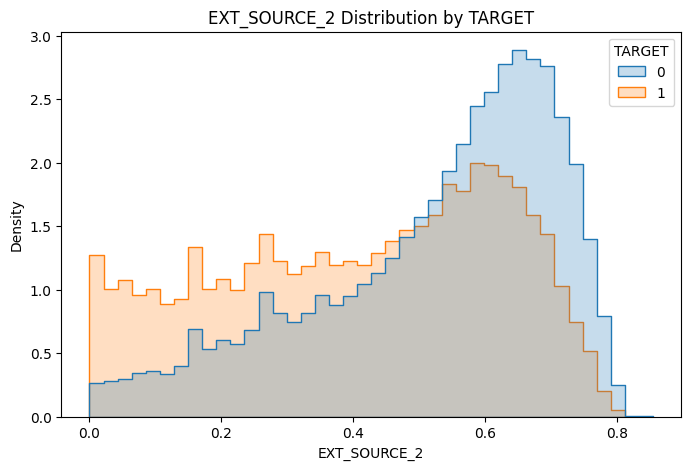

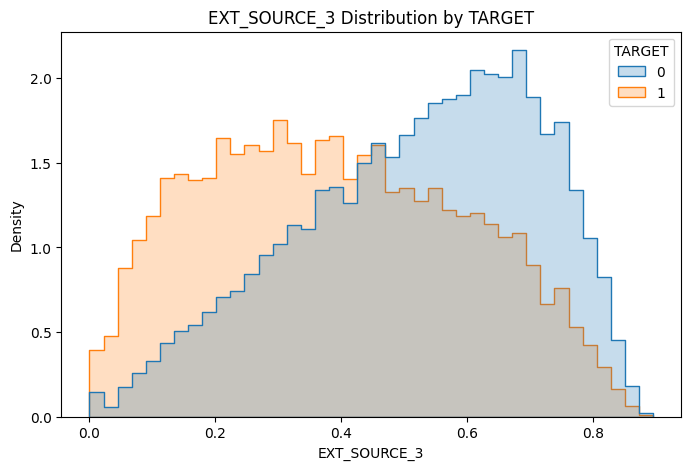

In [55]:
# Distribution split by TARGET - does the score actually separate defaulters?
for col in ext_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(data=df, x=col, hue='TARGET', bins=40,
                 element='step', stat='density', common_norm=False)
    plt.title(f'{col} Distribution by TARGET')
    plt.show()

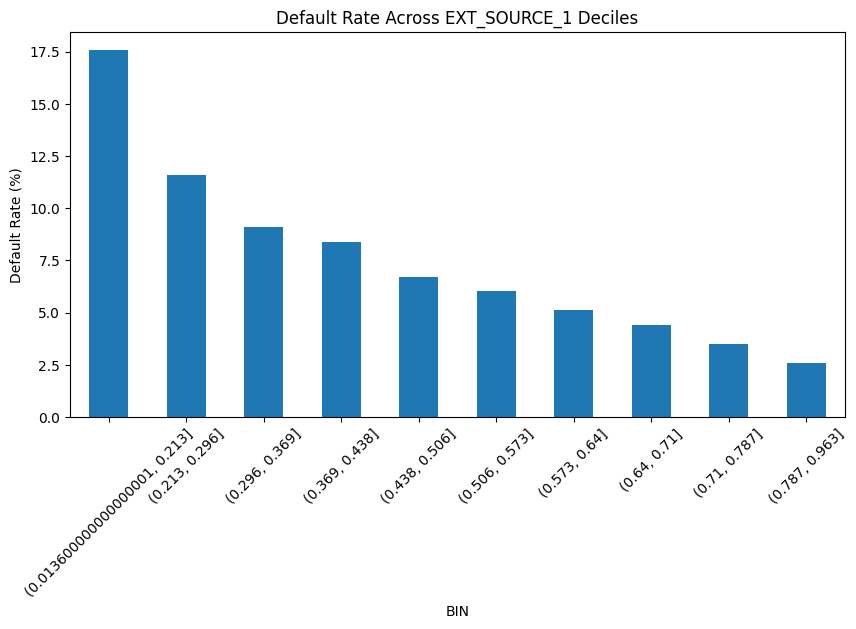

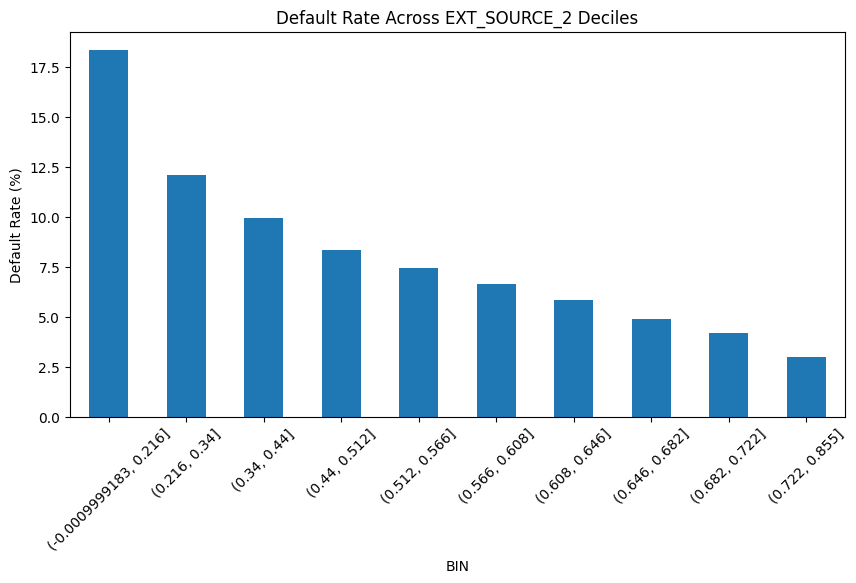

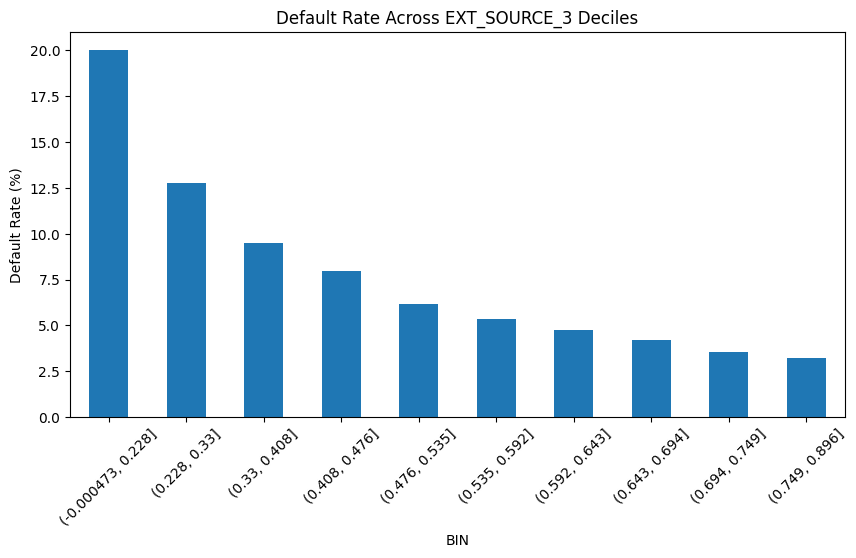

In [56]:
# Default rate by decile - cleanest way to see if the score is monotonic
for col in ext_cols:
    temp = df[[col, 'TARGET']].dropna().copy()
    temp['BIN'] = pd.qcut(temp[col], q=10, duplicates='drop')
    default_rate = temp.groupby('BIN', observed=False)['TARGET'].mean() * 100

    plt.figure(figsize=(10,5))
    default_rate.plot(kind='bar')
    plt.title(f'Default Rate Across {col} Deciles')
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45)
    plt.show()

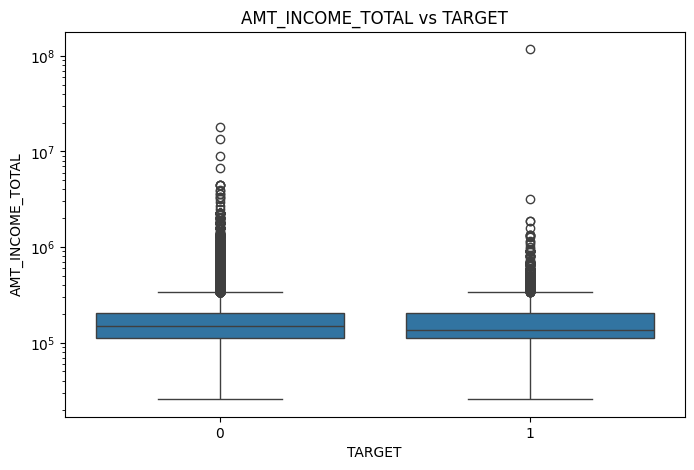

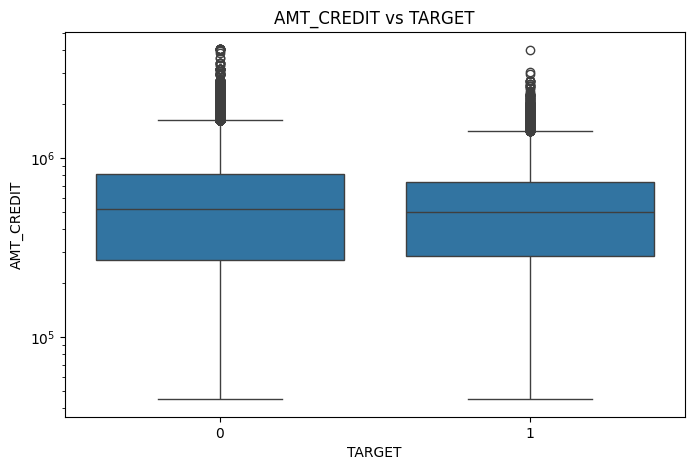

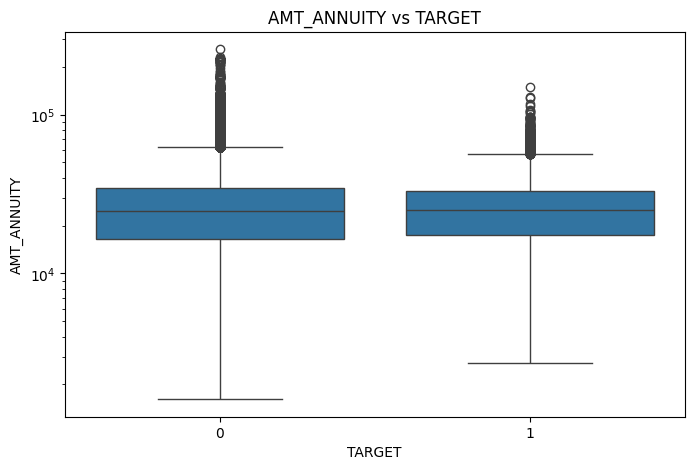

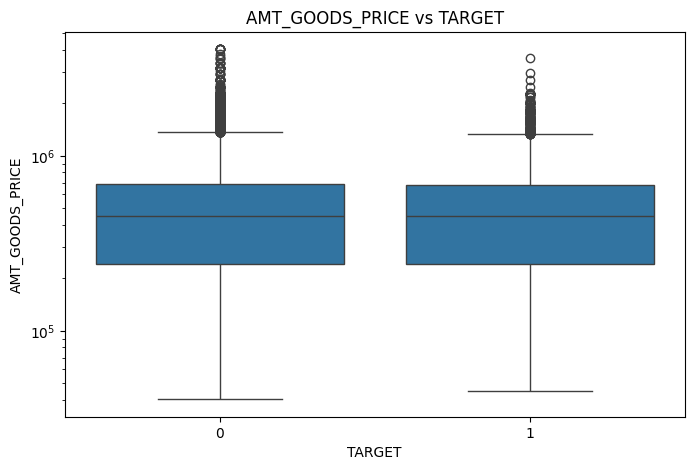

In [57]:
financial_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

for col in financial_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='TARGET', y=col)
    plt.yscale('log')   # these are heavily right-skewed, log scale makes boxplots readable
    plt.title(f'{col} vs TARGET')
    plt.show()

In [58]:
for col in financial_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col} | Outliers: {outliers} | Pct: {round(outliers/len(df)*100, 2)}%")

AMT_INCOME_TOTAL | Outliers: 14035 | Pct: 4.56%
AMT_CREDIT | Outliers: 6562 | Pct: 2.13%
AMT_ANNUITY | Outliers: 7504 | Pct: 2.44%
AMT_GOODS_PRICE | Outliers: 14728 | Pct: 4.79%


In [59]:
missing_check_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
                       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'OCCUPATION_TYPE']

for col in missing_check_cols:
    result = df.groupby(df[col].isna())['TARGET'].mean() * 100
    print(f"\n--- {col} ---")
    print(result)


--- EXT_SOURCE_1 ---
EXT_SOURCE_1
False    7.495545
True     8.519535
Name: TARGET, dtype: float64

--- EXT_SOURCE_2 ---
EXT_SOURCE_2
False    8.073299
True     7.878788
Name: TARGET, dtype: float64

--- EXT_SOURCE_3 ---
EXT_SOURCE_3
False    7.766502
True     9.311900
Name: TARGET, dtype: float64

--- AMT_ANNUITY ---
AMT_ANNUITY
False    8.073197
True     0.000000
Name: TARGET, dtype: float64

--- AMT_GOODS_PRICE ---
AMT_GOODS_PRICE
False    8.073351
True     7.553957
Name: TARGET, dtype: float64

--- OCCUPATION_TYPE ---
OCCUPATION_TYPE
False    8.785051
True     6.513056
Name: TARGET, dtype: float64


In [60]:
df['AMT_ANNUITY'].isnull().sum()

np.int64(12)

In [61]:
df[df['OCCUPATION_TYPE'].isnull()]['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,55357
Working,24920
Commercial associate,12297
State servant,3787
Unemployed,22
Student,5
Businessman,2
Maternity leave,1
